<a href="https://colab.research.google.com/github/ameliagarciarond22-source/Fundamentos-de-IA/blob/main/Regresion_Lineal_Dataset2_Yolotzin_Alcantara.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Regresión Lineal — Dataset 2: Cultivo

Predicción del **rendimiento (kg/ha)** a partir del **fertilizante (kg/ha)** y las **horas de sol**.

Para obtener los parámetros de los modelos se utilizan las ecuaciones normales:

$$(X^TX)w=X^Ty$$

El sistema se resuelve directamente usando `np.linalg.solve`, sin calcular la inversa de la matriz.

In [48]:
# Importar librerías
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

In [67]:
# 1. Cargar el dataset"
datos = pd.read_csv('dataset2_cultivo.csv')

print("Dimensiones:", datos.shape)

datos.head()

Dimensiones: (50, 3)


,fertilizante_kg_ha,horas_sol,rendimiento_kg_ha
0,165.3,10.22,93.6
1,179.2,11.77,85.0
2,28.0,8.01,72.0
3,110.8,5.15,95.9
4,21.7,4.11,49.6


In [68]:
datos.info()
datos.describe() #tipo de datos y algunos valores estadísticos.

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 50 entries, 0 to 49
Data columns (total 3 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   fertilizante_kg_ha  50 non-null     float64
 1   horas_sol           50 non-null     float64
 2   rendimiento_kg_ha   50 non-null     float64
dtypes: float64(3)
memory usage: 1.3 KB


,fertilizante_kg_ha,horas_sol,rendimiento_kg_ha
count,50.000,50.000000,50.000000
mean,104.040,8.038400,85.468000
std,61.659,2.373174,16.250531
min,7.500,4.110000,49.600000
25%,48.950,5.845000,72.375000
50%,107.300,8.150000,83.950000
75%,164.400,10.142500,95.475000
max,198.500,11.770000,129.100000


## 2. Definición de variables

- $x_1$: fertilizante (kg/ha)
- $x_2$: horas de sol
- $y$: rendimiento (kg/ha)

In [69]:
x1 = datos['fertilizante_kg_ha'].values
x2 = datos['horas_sol'].values
y = datos['rendimiento_kg_ha'].values

print("Fertilizante:", x1[:5])
print("Horas de sol:", x2[:5])
print("Rendimiento:", y[:5])

Fertilizante: [165.3 179.2  28.  110.8  21.7]
Horas de sol: [10.22 11.77  8.01  5.15  4.11]
Rendimiento: [93.6 85.  72.  95.9 49.6]


## 3. Análisis exploratorio

Primero observamos la relación entre el fertilizante y el rendimiento.

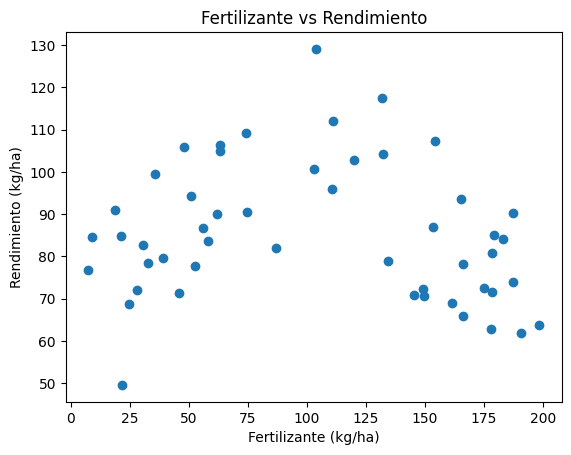

In [70]:
#Gráfica fertilizante vs rendimiento
plt.scatter(x1, y)

plt.xlabel("Fertilizante (kg/ha)")
plt.ylabel("Rendimiento (kg/ha)")
plt.title("Fertilizante vs Rendimiento")

plt.show()

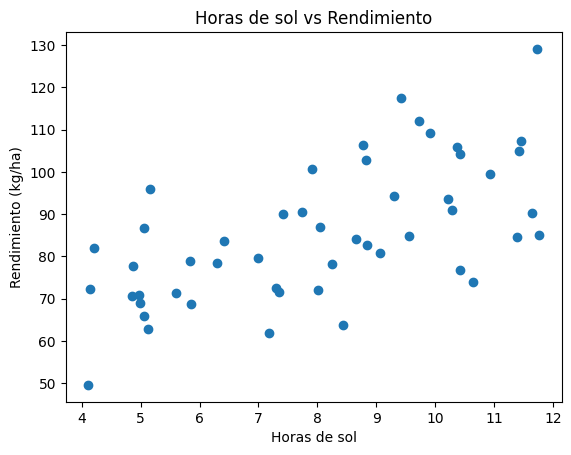

In [71]:
#Gráfica horas de sol vs rendimiento
plt.scatter(x2, y)

plt.xlabel("Horas de sol")
plt.ylabel("Rendimiento (kg/ha)")
plt.title("Horas de sol vs Rendimiento")

plt.show()

In [72]:
#Correlación (qué tan relacionadas están las variables.)
datos.corr(numeric_only=True)

,fertilizante_kg_ha,horas_sol,rendimiento_kg_ha
fertilizante_kg_ha,1.00000,-0.015540,-0.141230
horas_sol,-0.01554,1.000000,0.625388
rendimiento_kg_ha,-0.14123,0.625388,1.000000


## 4. Modelo 1: Regresión lineal múltiple

El primer modelo es:

$$
y=w_0+w_1x_1+w_2x_2
$$

La matriz $X$ es:

$$
X=
\begin{pmatrix}
1 & x_1 & x_2
\end{pmatrix}
$$

Los parámetros se obtienen mediante las ecuaciones normales:

$$
(X^TX)w=X^Ty
$$

In [73]:
#Construir la matriz
unos = np.ones(len(x1))

X1 = np.column_stack((unos, x1, x2))

print("Matriz X1:")
print(X1)

Matriz X1:
[[  1.   165.3   10.22]
 [  1.   179.2   11.77]
 [  1.    28.     8.01]
 [  1.   110.8    5.15]
 [  1.    21.7    4.11]
 [  1.   134.4    5.84]
 [  1.    56.2    5.05]
 [  1.   131.9    9.42]
 [  1.   145.4    4.97]
 [  1.   153.7    8.05]
 [  1.    21.5    9.55]
 [  1.   183.2    8.65]
 [  1.    46.     5.6 ]
 [  1.     7.5   10.43]
 [  1.   111.     9.72]
 [  1.    74.2    9.91]
 [  1.   166.     5.05]
 [  1.   161.7    4.99]
 [  1.    63.4   11.42]
 [  1.   190.6    7.18]
 [  1.    58.2    6.41]
 [  1.   103.     7.91]
 [  1.    51.2    9.3 ]
 [  1.   187.2   11.64]
 [  1.    32.9    6.29]
 [  1.     9.    11.4 ]
 [  1.    87.     4.2 ]
 [  1.   198.5    8.44]
 [  1.   178.3    9.07]
 [  1.   149.7    4.85]
 [  1.   178.2    5.12]
 [  1.   178.7    7.35]
 [  1.   103.8   11.73]
 [  1.    63.2    8.77]
 [  1.   154.4   11.46]
 [  1.   132.3   10.43]
 [  1.    74.7    7.74]
 [  1.    18.9   10.28]
 [  1.   149.4    4.14]
 [  1.    52.5    4.87]
 [  1.   187.4   10.64]
 [  1

In [74]:
#Resolver las ecuaciones normales
A1 = X1.T @ X1  #calcula:X^t(X)

b1 = X1.T @ y   #calcula:X^t(y)

w1 = np.linalg.solve(A1, b1)   #resuelve:((X^t)X)w = (X^t)y

print("A1 =")
print(A1)

print("b1 =")
print(b1)

print("w0 =", w1[0])
print("w1 =", w1[1])
print("w2 =", w1[2])

A1 =
[[5.0000000e+01 5.2020000e+03 4.0192000e+02]
 [5.2020000e+03 7.2750586e+05 4.1704336e+04]
 [4.0192000e+02 4.1704336e+04 3.5067596e+03]]
b1 =
[  4273.4   437670.46   35533.096]
w0 = 54.76380553960177
w1 = -0.034669033943369475
w2 = 4.268406741623505


In [75]:
#Predicciones del modelo 1
y_pred1 = X1 @ w1

print("Primeras predicciones:")
print(y_pred1[:5])

Primeras predicciones:
[92.65613113 98.79026201 87.98301059 72.9047713  71.55463921]


In [76]:
#Calcular MSE
mse1 = np.mean((y - y_pred1)**2)

print("MSE del Modelo 1 =", mse1)

MSE del Modelo 1 = 153.10237847321443


In [77]:
#Calcular R^2
suma_errores = np.sum((y - y_pred1)**2)

suma_total = np.sum((y - np.mean(y))**2)

r2_1 = 1 - suma_errores / suma_total

print("R^2 del Modelo 1 =", r2_1)

R^2 del Modelo 1 = 0.40841013317955355


In [78]:
print("Modelo 1:")

print("y =", w1[0], "+", w1[1], "* x1 +", w1[2], "* x2")

Modelo 1:
y = 54.76380553960177 + -0.034669033943369475 * x1 + 4.268406741623505 * x2


## 5. Modelo 2: Segundo grado

Ahora agregamos términos cuadráticos:

$$
y=w_0+w_1x_1+w_2x_2+w_3x_1^2+w_4x_2^2
$$

Por lo tanto, la matriz $X$ contiene las columnas:

$$
1,\quad x_1,\quad x_2,\quad x_1^2,\quad x_2^2
$$

In [79]:
#Construir la matriz X2

X2 = np.column_stack((
    unos,
    x1,
    x2,
    x1**2,
    x2**2
))

print("Matriz X2:")
print(X2)

Matriz X2:
[[1.000000e+00 1.653000e+02 1.022000e+01 2.732409e+04 1.044484e+02]
 [1.000000e+00 1.792000e+02 1.177000e+01 3.211264e+04 1.385329e+02]
 [1.000000e+00 2.800000e+01 8.010000e+00 7.840000e+02 6.416010e+01]
 [1.000000e+00 1.108000e+02 5.150000e+00 1.227664e+04 2.652250e+01]
 [1.000000e+00 2.170000e+01 4.110000e+00 4.708900e+02 1.689210e+01]
 [1.000000e+00 1.344000e+02 5.840000e+00 1.806336e+04 3.410560e+01]
 [1.000000e+00 5.620000e+01 5.050000e+00 3.158440e+03 2.550250e+01]
 [1.000000e+00 1.319000e+02 9.420000e+00 1.739761e+04 8.873640e+01]
 [1.000000e+00 1.454000e+02 4.970000e+00 2.114116e+04 2.470090e+01]
 [1.000000e+00 1.537000e+02 8.050000e+00 2.362369e+04 6.480250e+01]
 [1.000000e+00 2.150000e+01 9.550000e+00 4.622500e+02 9.120250e+01]
 [1.000000e+00 1.832000e+02 8.650000e+00 3.356224e+04 7.482250e+01]
 [1.000000e+00 4.600000e+01 5.600000e+00 2.116000e+03 3.136000e+01]
 [1.000000e+00 7.500000e+00 1.043000e+01 5.625000e+01 1.087849e+02]
 [1.000000e+00 1.110000e+02 9.720000e

In [80]:
#Resolver el modelo
A2 = X2.T @ X2

b2 = X2.T @ y

w2 = np.linalg.solve(A2, b2)

print("w0 =", w2[0])
print("w1 =", w2[1])
print("w2 =", w2[2])
print("w3 =", w2[3])
print("w4 =", w2[4])

w0 = 15.317652463837154
w1 = 0.8774243634196416
w2 = 5.55894974767516
w3 = -0.004410655787135584
w4 = -0.023474467055678145


In [81]:
#Predicciones, MSE Y R^2
y_pred2 = X2 @ w2

mse2 = np.mean((y - y_pred2)**2)

suma_errores2 = np.sum((y - y_pred2)**2)

suma_total2 = np.sum((y - np.mean(y))**2)

r2_2 = 1 - suma_errores2 / suma_total2

print("MSE del Modelo 2 =", mse2)
print("R^2 del Modelo 2 =", r2_2)

MSE del Modelo 2 = 24.49319172604023
R^2 del Modelo 2 = 0.9053579429940023


In [82]:
#Ecuacion del modelo 2
print("Modelo 2:")

print("y =", w2[0], "+", w2[1], "* x1 +", w2[2],
      "* x2 +", w2[3], "* x1^2 +", w2[4], "* x2^2")

Modelo 2:
y = 15.317652463837154 + 0.8774243634196416 * x1 + 5.55894974767516 * x2 + -0.004410655787135584 * x1^2 + -0.023474467055678145 * x2^2


## 6. Modelo 3: Segundo grado con interacción

En este modelo agregamos también el término de interacción $x_1x_2$:

$$
y=w_0+w_1x_1+w_2x_2+w_3x_1^2+w_4x_1x_2+w_5x_2^2
$$

La interacción permite considerar el efecto conjunto entre el fertilizante y las horas de sol.

In [83]:
#Construir X_3
X3 = np.column_stack((
    unos,
    x1,
    x2,
    x1**2,
    x1*x2,
    x2**2
))

print("Matriz X3:")
print(X3)

Matriz X3:
[[1.000000e+00 1.653000e+02 1.022000e+01 2.732409e+04 1.689366e+03
  1.044484e+02]
 [1.000000e+00 1.792000e+02 1.177000e+01 3.211264e+04 2.109184e+03
  1.385329e+02]
 [1.000000e+00 2.800000e+01 8.010000e+00 7.840000e+02 2.242800e+02
  6.416010e+01]
 [1.000000e+00 1.108000e+02 5.150000e+00 1.227664e+04 5.706200e+02
  2.652250e+01]
 [1.000000e+00 2.170000e+01 4.110000e+00 4.708900e+02 8.918700e+01
  1.689210e+01]
 [1.000000e+00 1.344000e+02 5.840000e+00 1.806336e+04 7.848960e+02
  3.410560e+01]
 [1.000000e+00 5.620000e+01 5.050000e+00 3.158440e+03 2.838100e+02
  2.550250e+01]
 [1.000000e+00 1.319000e+02 9.420000e+00 1.739761e+04 1.242498e+03
  8.873640e+01]
 [1.000000e+00 1.454000e+02 4.970000e+00 2.114116e+04 7.226380e+02
  2.470090e+01]
 [1.000000e+00 1.537000e+02 8.050000e+00 2.362369e+04 1.237285e+03
  6.480250e+01]
 [1.000000e+00 2.150000e+01 9.550000e+00 4.622500e+02 2.053250e+02
  9.120250e+01]
 [1.000000e+00 1.832000e+02 8.650000e+00 3.356224e+04 1.584680e+03
  7.48225

In [84]:
#Resolver modelo 3
A3 = X3.T @ X3

b3 = X3.T @ y

w3 = np.linalg.solve(A3, b3)

print("w0 =", w3[0])
print("w1 =", w3[1])
print("w2 =", w3[2])
print("w3 =", w3[3])
print("w4 =", w3[4])
print("w5 =", w3[5])

w0 = 13.529993319264227
w1 = 0.8979744314251178
w2 = 5.719682365491131
w3 = -0.004414080289094728
w4 = -0.0023771339134705245
w5 = -0.017911500492816836


In [ ]:
#Predicciones, MSE Y R^2
y_pred3 = X3 @ w3

mse3 = np.mean((y - y_pred3)**2)

suma_errores3 = np.sum((y - y_pred3)**2)

suma_total3 = np.sum((y - np.mean(y))**2)

r2_3 = 1 - suma_errores3 / suma_total3

print("MSE del Modelo 3 =", mse3)
print("R^2 del Modelo 3 =", r2_3)

In [ ]:
#Ecuacion del modelo 3
print("Modelo 3:")

print("y =", w3[0], "+", w3[1], "* x1 +", w3[2],
      "* x2 +", w3[3], "* x1^2 +", w3[4],
      "* x1*x2 +", w3[5], "* x2^2")

## 7. Comparación de modelos

Se comparan los modelos utilizando el MSE y el coeficiente $R^2$.

Un MSE menor indica menor error de predicción, mientras que un $R^2$ más cercano a 1 indica un mejor ajuste.

In [85]:
print("MODELO 1")
print("MSE =", mse1)
print("R^2 =", r2_1)

print()

print("MODELO 2")
print("MSE =", mse2)
print("R^2 =", r2_2)

print()

print("MODELO 3")
print("MSE =", mse3)
print("R^2 =", r2_3)

MODELO 1
MSE = 153.10237847321443
R^2 = 0.40841013317955355

MODELO 2
MSE = 24.49319172604023
R^2 = 0.9053579429940023

MODELO 3
MSE = 24.382789510396627
R^2 = 0.9057845387967625


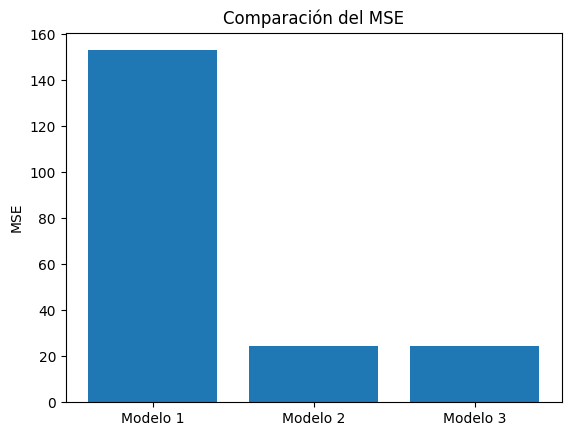

In [86]:
#Grafica de comparacion del MSE
modelos = ["Modelo 1", "Modelo 2", "Modelo 3"]

mse = [mse1, mse2, mse3]

plt.bar(modelos, mse)

plt.ylabel("MSE")
plt.title("Comparación del MSE")

plt.show()

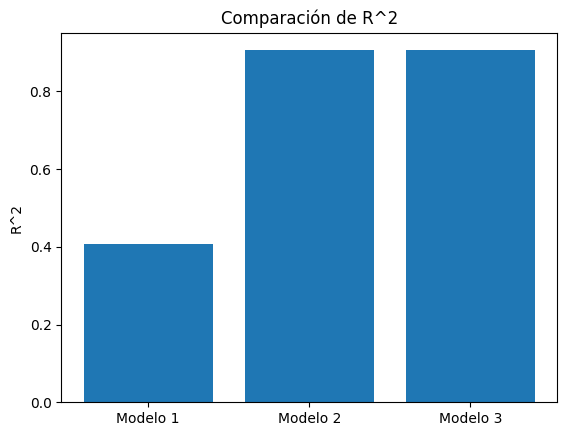

In [87]:
#Grafica de comparacion de R^2
r2 = [r2_1, r2_2, r2_3]

plt.bar(modelos, r2)

plt.ylabel("R^2")
plt.title("Comparación de R^2")

plt.show()

## 9. Conclusión

Se analizaron tres modelos de regresión para predecir el rendimiento de los cultivos utilizando como variables el fertilizante y las horas de sol.

El primer modelo considera únicamente los términos lineales. El segundo agrega los términos cuadráticos $x_1^2$ y $x_2^2$, mientras que el tercer modelo también incluye el término de interacción $x_1x_2$.

Los parámetros de los tres modelos se obtuvieron mediante las ecuaciones normales:

$$(X^TX)w=X^Ty$$

y el sistema se resolvió utilizando `np.linalg.solve`, evitando calcular directamente la inversa de la matriz.

Para comparar los modelos se utilizaron el Error Cuadrático Medio (error promedio) y $R^2$. El modelo con menor MSE y mayor $R^2$ representa un mejor ajuste a los datos. Sin embargo, si dos modelos presentan resultados similares, puede ser conveniente elegir el modelo más sencillo.

## Gráfica 3D de los datos

Se muestra la relación entre fertilizante, horas de sol y rendimiento.

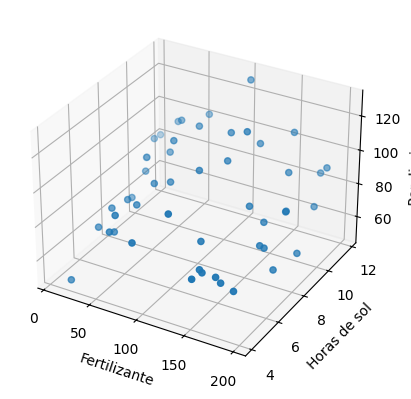

In [88]:
fig = plt.figure()

ax = fig.add_subplot(111, projection="3d")

ax.scatter(x1, x2, y)

ax.set_xlabel("Fertilizante")
ax.set_ylabel("Horas de sol")
ax.set_zlabel("Rendimiento")

plt.show()